# 0. Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
import seaborn as sns
import umap
import time
import gc

/home/marina/Software/XRB_ML/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 1. Constants & functions

In [2]:
# UMAP & PCA
random_state = 42 # for reproducibility
test_size = 0.2 # standard choice
n_components = 2 # Number of reduced dimensions. Note that the scatter plots will show 2D no matter n_components. 
                 # n_components must be lower than the number of features.

# UMAP
n_neighbors = 3
min_dist = 0
metric = "braycurtis" # This controls how distance is computed in the ambient space of the input data. 
                       # Check https://umap-learn.readthedocs.io/en/latest/parameters.html for more options.
init="random" # works better for reproducibility than the default option 'spectral' when random_state is fixed, moreover with non
              # conventional metrics (like jaccard)

# Random forest
search_type = "grid_search" # For Random forest. Choose between random_search (faster) or grid_search (exhaustive, more expensive)

#############
fontsize = 14 # not relevant for training and testing classifiers, just for labels and numbers in figures

In [3]:
def PrincipalComponentAnalysis(X_train, y_train, Experiment_ID):
    pca = PCA(n_components=n_components)
    X2D = pca.fit_transform(X_train)
    fig, ax = plt.subplots()

    ax.set_xlabel("PC1", fontsize=fontsize)
    ax.set_ylabel("PC2", fontsize=fontsize)
    plt.xticks(fontsize=fontsize)
    plt.yticks(fontsize=fontsize)
    plt.gca().set_aspect('equal', adjustable='box')
    ax.scatter(X2D[y_train == 'HMXB', 0], X2D[y_train == 'HMXB', 1], s=15, marker='o', color='black', label='HMXB')
    ax.scatter(X2D[y_train == 'LMXB', 0], X2D[y_train == 'LMXB', 1], s=15, marker='.', color='lightgrey', label='LMXB')    
    plt.savefig('Patterns_PCA_{}.pdf'.format(Experiment_ID), dpi=300, bbox_inches='tight') 
    return pca

def logistic_pipeline(X_train, X_test, y_train, y_test, feature_names, Experiment_ID):
    logistic = LogisticRegression(max_iter=1000, tol=0.1, random_state=random_state)
    # Create the pipeline with scaling, PCA and the classifier
    pipe = Pipeline([
        ("pca", PCA(n_components=n_components, random_state=random_state)), 
        ("logistic", logistic)
    ])
        
    # Train the pipeline on the training data
    pipe.fit(X_train, y_train)
    # Make the prediction on the test data
    y_pred = pipe.predict(X_test)
    # Recover PCA from pipeline
    pca = pipe.named_steps['pca']

    explained_variance_ratio = pca.explained_variance_ratio_
    total_explained_variance = explained_variance_ratio.sum()

    print("explained_variance_ratio:", explained_variance_ratio)
    print("total_explained_variance (explained_variance_ratio.sum()):", total_explained_variance)

    # Most representative features in each component
    for i in range(pca.n_components):
        max_feature_index = pca.components_[i].argmax()
        print(f"Component {i + 1}: {feature_names[max_feature_index]}")
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.2f}")
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred, labels=['HMXB', 'LMXB']))
    cm = confusion_matrix(y_test, y_pred, labels=['HMXB', 'LMXB'])

    # Create heatmap of confusion matrix
    plt.figure(figsize=(2,2))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greys", cbar=False, annot_kws={"size": 14})

    plt.xlabel("Predicted Label", fontsize=fontsize)
    plt.ylabel("True Label", fontsize=fontsize)
    plt.xticks([0.5, 1.5], ["HMXB", "LMXB"], fontsize=fontsize)
    plt.yticks([0.5, 1.5], ["HMXB", "LMXB"], fontsize=fontsize)

    plt.tight_layout()
    plt.savefig("ConfusionMatrix_PCA_LogisticRegresion_{}.pdf".format(Experiment_ID), dpi=300)
    plt.show()

    return

def umap_reducer(X_train, X_test, y_train, Experiment_ID):
    reducer = umap.UMAP(n_components=n_components, random_state=random_state, n_neighbors=n_neighbors, min_dist=min_dist, metric=metric,
                       init=init, n_jobs=-1)
    X_train_reduced = reducer.fit_transform(X_train)
    
    df_plot = pd.DataFrame({"0": X_train_reduced[:, 0], "1": X_train_reduced[:, 1], "Class": y_train})
    fig, ax = plt.subplots(figsize=(6, 6)) 
    ax.set_xlabel("UMAP1", fontsize=fontsize)
    ax.set_ylabel("UMAP2", fontsize=fontsize)
    ax.scatter(df_plot[df_plot["Class"] == "HMXB"]["0"], df_plot[df_plot["Class"] == "HMXB"]["1"],
               s=15, marker='o', color='black')
    ax.scatter(df_plot[df_plot["Class"] == "LMXB"]["0"], df_plot[df_plot["Class"] == "LMXB"]["1"],
               s=15, marker='.', color='lightgrey')
    ax.set_aspect('equal', adjustable='box')
    ax.tick_params(axis='both', labelsize=fontsize)
    plt.tight_layout()
    plt.savefig('Patterns_UMAP_{}.pdf'.format(Experiment_ID), dpi=300)
    
    X_test_reduced = reducer.transform(X_test)
    return X_train_reduced, X_test_reduced

def evaluate_model(model, X_test, y_test, le):
    '''
    Evaluates the performance of a machine learning model on test data.
    Parameters:
    - model: The trained machine learning model.
    - X_test: The feature matrix of the test data.
    - y_test: The target labels of the test data.
    - le: label encoder.
    Returns:
    - df: A pandas DataFrame containing the evaluation metrics for each class and the weighted average.
    '''
    predictions = model.predict(X_test)
    precision = precision_score(y_test, predictions, average=None, labels=le.transform(le.classes_))                   
    recall = recall_score(y_test, predictions, average=None, labels=le.transform(le.classes_))
    f1 = f1_score(y_test, predictions, average=None, labels=le.transform(le.classes_))
    labels=le.classes_
    df = pd.DataFrame([
        dict(Class=labels[i],
            Precision=precision[i],
            Recall=recall[i],
            F1=f1[i],
            ) for i in range(len(labels))
            ])
    d = {
        "Class": "Weighted Average",
        "Precision": precision_score(y_test, predictions, average="weighted"),
        "Recall": recall_score(y_test, predictions, average="weighted"),
        "F1": f1_score(y_test, predictions, average="weighted"),
        }
    df = pd.concat([df, pd.DataFrame([d])], ignore_index=True)    
    df[["Precision", "Recall", "F1"]] = df[["Precision", "Recall", "F1"]].round(3)    

    return df.set_index("Class")

def train_classifier(X_train, X_test, y_train, y_test, search_type, Experiment_ID):
    start_time = time.time()
    le = LabelEncoder()
    y_train = le.fit_transform(y_train)
    y_test = le.transform(y_test)
    # Find the best combination of parameters for the classifier
    pipe = Pipeline([
    ('clf',  RandomForestClassifier(random_state=random_state))
    ])
    param_grid = {
    "clf__n_estimators": [5, 10, 50, 100, 200],
    "clf__max_depth": [None, 5, 10, 20, 30],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 4],
    "clf__criterion": ["gini", "entropy"],
    "clf__max_features": [None, "sqrt", "log2"], 
    }
    scoring = "f1_weighted"
    if search_type == "random_search":
        pipeline = RandomizedSearchCV(pipe, param_grid, n_iter=200, cv=5, n_jobs=-1, verbose=0, scoring=scoring, random_state=random_state)
    elif search_type == "grid_search":
        pipeline = GridSearchCV(pipe, param_grid, cv=5, n_jobs=-1, verbose=0, scoring=scoring)
    else:
        raise ValueError("search_type not valid. Choose between 'random_search' and 'grid_search'.")
    pipeline.fit(X_train, y_train)   
    best_model = pipeline.best_estimator_
    print("Best parameters found: ", pipeline.best_params_)
    print("\nBest score found: ", round(pipeline.best_score_, 3))
    
    # Evaluate model
    evaluation_result = evaluate_model(best_model, X_test, y_test, le) 
    predictions = best_model.predict(X_test)
    print(evaluation_result, "\nAccuracy: {}".format(round(accuracy_score(y_test, predictions), 3)))

    # Plot confusion matrix
    cm = confusion_matrix(y_test, predictions, labels=le.transform(le.classes_))
    plt.figure(figsize=(2,2))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greys", cbar=False, annot_kws={"size": 14})
    plt.xlabel("Predicted Label", fontsize=fontsize)
    plt.ylabel("True Label", fontsize=fontsize)
    plt.xticks([0.5, 1.5], ["HMXB", "LMXB"], fontsize=fontsize)
    plt.yticks([0.5, 1.5], ["HMXB", "LMXB"], fontsize=fontsize)
    plt.tight_layout()
    plt.savefig('ConfusionMatrix_RandomForest_{}.pdf'.format(Experiment_ID), dpi=300)
    plt.show()
    
    elapsed_time = time.time() - start_time
    return elapsed_time

# 2. Read data

In [4]:
df_HMXB = pd.read_csv("HMXB.csv", sep=',', comment='#')
df_LMXB = pd.read_csv("LMXB.csv", sep=',', comment='#')

# Add labels before merging
df_HMXB['Class'] = 'HMXB'
df_LMXB['Class'] = 'LMXB'

df = pd.concat([df_HMXB, df_LMXB], ignore_index=True)

# New features defined by Perez-Díaz+2024:
df['var_ratio_b'] = df['var_mean_b'] / df['var_sigma_b']
df['var_ratio_h'] = df['var_mean_h'] / df['var_sigma_h']
df['var_ratio_s'] = df['var_mean_s'] / df['var_sigma_s']
df['var_newq_b'] = (df['var_max_b'] + df['var_min_b']) / (2 * df['var_mean_b'])

# Perez-Díaz+2024 feature selection
df = df[['hard_hm', 'hard_hs', 'hard_ms', 'bb_kt', 'powlaw_gamma', 'var_prob_b', 
         'var_prob_h', 'var_prob_s', 'var_ratio_b', 'var_ratio_h', 'var_ratio_s', 'var_newq_b', 'Class']]

feature_names = df.drop(['Class'], axis=1).columns.tolist()

### Experiment 1
Clean NaNs and inf values (from sigma == 0):

In [5]:
df_exp1 = df[~df.isin([np.inf, -np.inf]).any(axis=1)].dropna()
X = df_exp1.drop(['Class'], axis=1)
y = df_exp1["Class"]
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X, y, test_size=test_size, random_state=random_state)
scaler = StandardScaler().fit(X_train_1)
X_train_1 = scaler.transform(X_train_1)
X_test_1 = scaler.transform(X_test_1)

print(len(df_exp1))
del X, y
gc.collect()

327


27514

### Experiment 2
Replace inf values (from sigma==0) and NaNs with mean by column, not distinguishing between HMXB and LMXB:

In [6]:
df_exp2 = df.copy()
df_exp2 = df_exp2.replace([np.inf, -np.inf], np.nan)
X = df_exp2.drop(['Class'], axis=1)
y = df_exp2["Class"]
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X, y, test_size=test_size, random_state=random_state)
imputer = SimpleImputer(strategy='mean')
imputer.fit(X_train_2)
X_train_imputed = imputer.transform(X_train_2)
X_train_2 = pd.DataFrame(X_train_imputed, columns=X_train_2.columns, index=X_train_2.index)
X_test_imputed = imputer.transform(X_test_2)
X_test_2 = pd.DataFrame(X_test_imputed, columns=X_test_2.columns, index=X_test_2.index)
scaler = StandardScaler().fit(X_train_2)
X_train_2 = scaler.transform(X_train_2)
X_test_2 = scaler.transform(X_test_2)

print(len(df_exp2))
del df, X, y
gc.collect()

1172


0

# 3. Intrinsic dimensionality using PCA

## 3.1 Visualization of patterns

### 3.1.1 Experiment 1

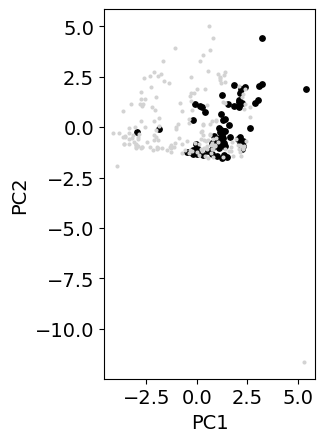

In [7]:
pca_exp1 = PrincipalComponentAnalysis(X_train_1, y_train_1, "Experiment_1")

In [8]:
pca_exp1.explained_variance_ratio_

array([0.29152095, 0.19604702])

In [9]:
pca_exp1.explained_variance_ratio_.sum()

np.float64(0.4875679701941305)

In [10]:
for i in range(pca_exp1.n_components):
    print(feature_names[pca_exp1.components_[i].argmax()])

hard_hs
var_prob_b


### 3.1.2 Experiment 2

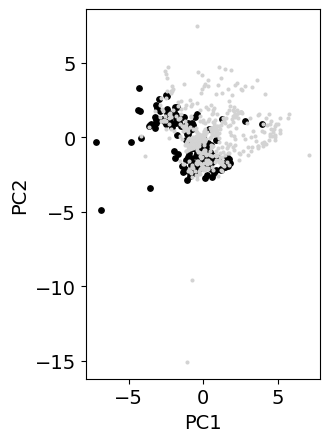

In [11]:
pca_exp2 = PrincipalComponentAnalysis(X_train_2, y_train_2, "Experiment_2")

In [12]:
pca_exp2.explained_variance_ratio_

array([0.19976046, 0.16669651])

In [13]:
pca_exp2.explained_variance_ratio_.sum()

np.float64(0.3664569735864232)

In [14]:
for i in range(pca_exp2.n_components):
    print(feature_names[pca_exp2.components_[i].argmax()])

powlaw_gamma
var_prob_b


## 3.2 Confusion matrix using logistic regression

### 3.2.1 Experiment 1

explained_variance_ratio: [0.29152095 0.19604702]
total_explained_variance (explained_variance_ratio.sum()): 0.4875679701941305
Component 1: hard_hs
Component 2: var_prob_b
Accuracy: 0.71
              precision    recall  f1-score   support

        HMXB       0.60      0.62      0.61        24
        LMXB       0.78      0.76      0.77        42

    accuracy                           0.71        66
   macro avg       0.69      0.69      0.69        66
weighted avg       0.71      0.71      0.71        66

[[15  9]
 [10 32]]


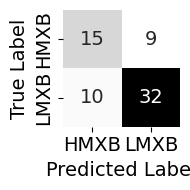

In [15]:
Experiment_ID = "Experiment_1"
logistic_pipeline(X_train_1, X_test_1, y_train_1, y_test_1, feature_names, Experiment_ID)

### 3.2.2 Experiment 2

explained_variance_ratio: [0.19976046 0.16669651]
total_explained_variance (explained_variance_ratio.sum()): 0.3664569735864232
Component 1: powlaw_gamma
Component 2: var_prob_b
Accuracy: 0.74
              precision    recall  f1-score   support

        HMXB       0.31      0.07      0.12        55
        LMXB       0.77      0.95      0.85       180

    accuracy                           0.74       235
   macro avg       0.54      0.51      0.48       235
weighted avg       0.66      0.74      0.68       235

[[  4  51]
 [  9 171]]


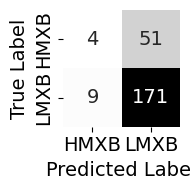

In [16]:
Experiment_ID = "Experiment_2"
logistic_pipeline(X_train_2, X_test_2, y_train_2, y_test_2, feature_names, Experiment_ID)

# 4. UMAP

## 4.1 Visualization of patterns

### 4.1.1 Experiment 1

/home/marina/Software/XRB_ML/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


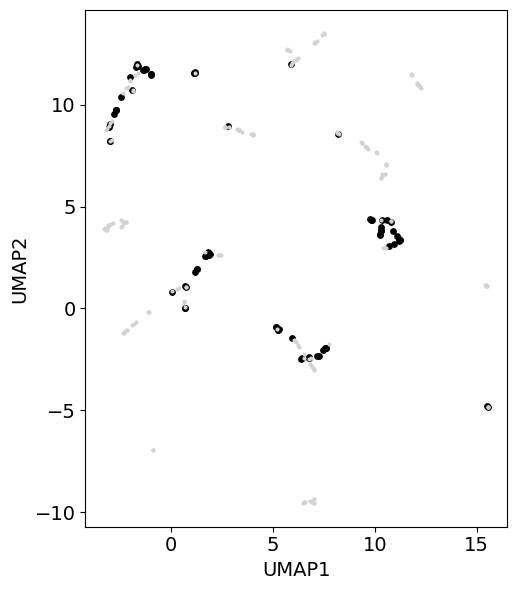

In [17]:
X_train_reduced_1, X_test_reduced_1 = umap_reducer(X_train_1, X_test_1, y_train_1, "Experiment_1" + "_" + metric)

### 4.1.2 Experiment 2

/home/marina/Software/XRB_ML/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


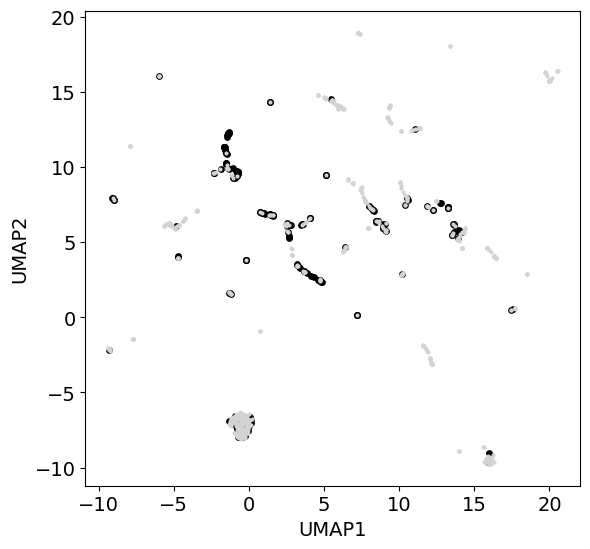

In [18]:
X_train_reduced_2, X_test_reduced_2 = umap_reducer(X_train_2, X_test_2, y_train_2, "Experiment_2" + "_" + metric)

## 4.2 Confusion matrices using random forest

### 4.2.a Without UMAP preprocessing

### 4.2.a.1 Experiment 1

Best parameters found:  {'clf__criterion': 'entropy', 'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 50}

Best score found:  0.893
                  Precision  Recall     F1
Class                                     
HMXB                  0.833   0.833  0.833
LMXB                  0.905   0.905  0.905
Weighted Average      0.879   0.879  0.879 
Accuracy: 0.879


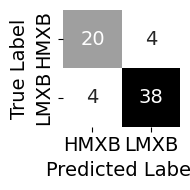

In [19]:
elapsed_time_a1 = train_classifier(X_train_1, X_test_1, y_train_1, y_test_1, search_type, "Experiment_1_without_UMAP")

### 4.2.a.2 Experiment 2

Best parameters found:  {'clf__criterion': 'entropy', 'clf__max_depth': None, 'clf__max_features': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}

Best score found:  0.841
                  Precision  Recall     F1
Class                                     
HMXB                  0.781   0.455  0.575
LMXB                  0.852   0.961  0.903
Weighted Average      0.836   0.843  0.826 
Accuracy: 0.843


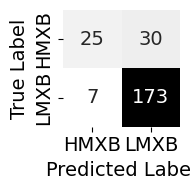

In [20]:
elapsed_time_a2 = train_classifier(X_train_2, X_test_2, y_train_2, y_test_2, search_type, "Experiment_2_without_UMAP")

### 4.2.b With UMAP preprocessing

### 4.2.b.1 Experiment 1

Best parameters found:  {'clf__criterion': 'gini', 'clf__max_depth': 10, 'clf__max_features': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 5, 'clf__n_estimators': 5}

Best score found:  0.839
                  Precision  Recall     F1
Class                                     
HMXB                  0.708   0.708  0.708
LMXB                  0.833   0.833  0.833
Weighted Average      0.788   0.788  0.788 
Accuracy: 0.788


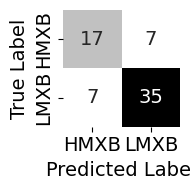

In [21]:
elapsed_time_b1 = train_classifier(X_train_reduced_1, X_test_reduced_1, y_train_1, y_test_1, search_type, 
                "Experiment_1_with_UMAP" + "_" + metric)

### 4.2.b.2 Experiment 2

Best parameters found:  {'clf__criterion': 'gini', 'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 5, 'clf__n_estimators': 50}

Best score found:  0.806
                  Precision  Recall     F1
Class                                     
HMXB                  0.579   0.400  0.473
LMXB                  0.832   0.911  0.870
Weighted Average      0.773   0.791  0.777 
Accuracy: 0.791


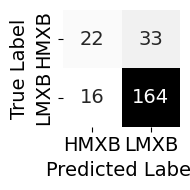

In [22]:
elapsed_time_b2 = train_classifier(X_train_reduced_2, X_test_reduced_2, y_train_2, y_test_2, search_type, 
                "Experiment_2_with_UMAP" + "_" + metric)

### 4.2.c Time performance

In [23]:
# Gain between applying random forest with and without preprocessing with UMAP
def calculate_percentage(a, b):
    if a == 0:
        return "Cannot calculate percentage with denominator 0."
    percentage = (a-b)/a * 100
    return percentage

result_exp1 = calculate_percentage(elapsed_time_a1, elapsed_time_b1)
result_exp2 = calculate_percentage(elapsed_time_a2, elapsed_time_b2)
print(f"UMAP preprocessing results in a {result_exp1:.2f}% reduction in computing time for Experiment 1")
print(f"UMAP preprocessing results in a {result_exp2:.2f}% reduction in computing time for Experiment 2")

UMAP preprocessing results in a 11.93% reduction in computing time for Experiment 1
UMAP preprocessing results in a 12.24% reduction in computing time for Experiment 2
